# TCCT S94D — Representation Sufficiency Audit

Audit-only replay of the eight revealed S94C zero-difference pairs. No training, tuning, freezing, or core modification is performed.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
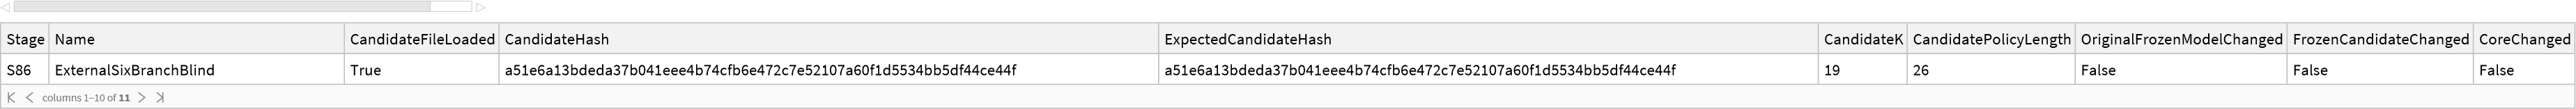

In [1902]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S94D, Name -> RepresentationSufficiencyAudit, AuditOnly -> True, 
 
>     DevelopmentOnly -> True, BlindTest -> False, PreflightPassed -> True, 
 
>     OriginalFrozenModelLocked -> True, S94AAuditLocked -> True, 
 
>     S94BResultLocked -> True, S94CDiagnosticArtifactsLocked -> True, 
 
>     CoreChanged -> False, TrainingRunYet -> False, 
 
>     DevelopmentCasesGeneratedYet -> False, CandidateFrozen -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, DevelopmentOnly, 
 
>      BlindTest, PreflightPassed, OriginalFrozenModelLocked, S94AAuditLocked, 
 
>      S94BResultLocked, S94CDiagnosticArtifactsLocked, CoreChanged, TrainingRunYet, 
 
>      DevelopmentCasesGeneratedYet, CandidateFrozen}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
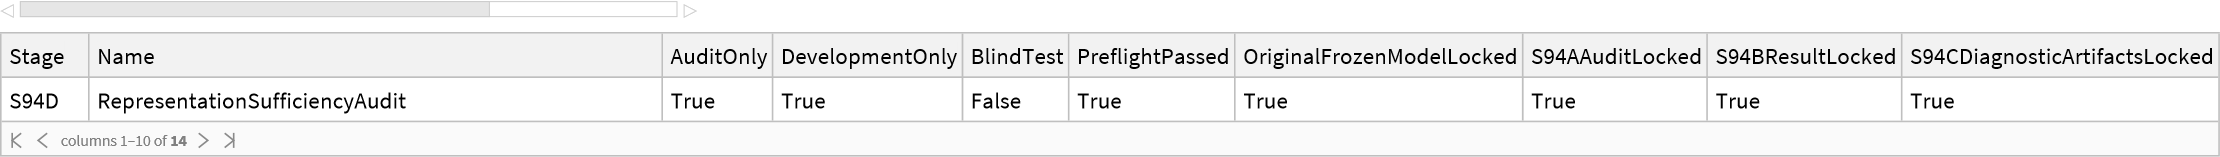

In [1990]:
expectedFrozenModelHash94D=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash94D=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash94D=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedBaseCandidateHash94D=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedBaseCandidateFileHash94D=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedBaseRuntimeFileHash94D=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedPairCandidateHash94D=
"540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c";
expectedPairCandidateFileHash94D=
"aecbe544a4af3a8ad0ba0494bb11312dd4a4b71f1a1c7ae42489a5300c7078ff";
expectedPairRuntimeFileHash94D=
"74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6";
expectedS94AAuditFileHash94D=
"ab0f6524f8cb8ee8edb915e132044734f8db8ce20758c09f26ded9de01571571";
expectedS94BResultHash94D=
"dc3de125d10d871c62857f051bbff204881512f63286bc0f3882791514724f9d";
expectedS94BCertificateFileHash94D=
"6b3c44566c80c88495f2a322a0763b7a188383445b554eefc30e7fa90b4e461f";
expectedS94BArtifactFileHash94D=
"998fa0de0fd8e14cf9c797287f64c824f7a435c2aa3c8b0b80b0a920075dc3e4";
expectedS94CDiagnosticResultHash94D=
"7b54af78cbef4204ceb006799d2650fd365f01ffad3dcf6de3194a8ffea0abfc";
expectedS94CCertificateFileHash94D=
"7281c001f977f6e8cc3c51b466bd7f48ce953a8465379e68116661ed8a7181e9";
expectedS94CArtifactFileHash94D=
"52aae85593e68fbc0bc8bd7ec1f1552e484e093156f334f65eff96b8889b6c7a";

k33CandidatePath94D="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
baseRuntimePath94D="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
baseCandidatePath94D="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
pairRuntimePath94D="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderRuntime.wl";
pairCandidatePath94D="E:/engine_wolf/TCCT_S92B_FrozenPairedContrastDecoder.wxf";
s94aAuditPath94D="E:/engine_wolf/TCCT_S94A_ModulusFeasibilityAudit.json";
s94bCertificatePath94D="E:/engine_wolf/TCCT_S94B_RoleAwareReadoutDevelopment.json";
s94bArtifactPath94D="E:/engine_wolf/TCCT_S94B_RoleAwareDevelopmentPairs.wxf";
s94cDiagnosticCertificatePath94D="E:/engine_wolf/TCCT_S94C_ExpandedRoleAwareReadoutDevelopment.json";
s94cDiagnosticArtifactPath94D="E:/engine_wolf/TCCT_S94C_ExpandedRoleAwareDevelopmentPairs.wxf";
resultCertificatePath94D="E:/engine_wolf/TCCT_S94D_RepresentationSufficiencyAudit.json";

ClearAll[FileSHA256Hex94D,CoreDefinitionBundle94D,
PairRuntimeDefinitionBundle94D];
FileSHA256Hex94D[path_String]:=If[FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],Missing["FileMissing",path]];
CoreDefinitionBundle94D[]:=CoreDefinitionBundle86[];
PairRuntimeDefinitionBundle94D[]:={DownValues[TCCTPairContrastVectorS92B],
DownValues[TCCTLoadFrozenPairDecoderS92B],
DownValues[TCCTPredictOrderedPairVectorsS92B],
DownValues[TCCTPredictOrderedPairWorldsS92B]};

requiredFiles94D={k33CandidatePath94D,baseRuntimePath94D,
baseCandidatePath94D,pairRuntimePath94D,pairCandidatePath94D,s94aAuditPath94D,
s94bCertificatePath94D,s94bArtifactPath94D,
s94cDiagnosticCertificatePath94D,s94cDiagnosticArtifactPath94D};
If[!And@@(FileExistsQ/@requiredFiles94D),
Print["S94D aborted: one or more locked inputs are missing."];
Dataset[AssociationThread[requiredFiles94D,FileExistsQ/@requiredFiles94D]];Abort[]];
If[FileExistsQ[resultCertificatePath94D]&&
FileByteCount[resultCertificatePath94D]>0,
Print["S94D aborted: a prior development certificate exists. Preserve it."];Abort[]];

fileHashesBefore94D=FileSHA256Hex94D/@requiredFiles94D;
Clear[frozenCandidate86E];Get[k33CandidatePath94D];
k33HashLoaded94D=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
Get[baseRuntimePath94D];
baseDecoderLoaded94D=Quiet@Check[
TCCTLoadFrozenDecoderS87D[baseCandidatePath94D],$Failed];
baseDecoderRaw94D=If[AssociationQ[baseDecoderLoaded94D],
KeyDrop[baseDecoderLoaded94D,{"Classifier"}],$Failed];
Get[pairRuntimePath94D];
pairDecoderLoaded94D=Quiet@Check[
TCCTLoadFrozenPairDecoderS92B[pairCandidatePath94D],$Failed];
pairDecoderRaw94D=If[AssociationQ[pairDecoderLoaded94D],
KeyDrop[pairDecoderLoaded94D,{"Policy"}],$Failed];
s94aAudit94D=Quiet@Check[Import[s94aAuditPath94D,"RawJSON"],$Failed];
s94bCertificate94D=Quiet@Check[Import[s94bCertificatePath94D,"RawJSON"],$Failed];
s94cDiagnosticCertificate94D=Quiet@Check[
Import[s94cDiagnosticCertificatePath94D,"RawJSON"],$Failed];
s94cDiagnosticArtifact94D=Quiet@Check[
Import[s94cDiagnosticArtifactPath94D,"WXF"],$Failed];

modelHashBefore94D=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore94D=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashBefore94D=Hash[Normal[baseDecoderRaw94D],"SHA256","HexString"];
pairDecoderObjectHashBefore94D=Hash[Normal[pairDecoderRaw94D],"SHA256","HexString"];
coreHashBefore94D=Hash[CoreDefinitionBundle94D[],"SHA256","HexString"];
canonicalizerHashBefore94D=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashBefore94D=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashBefore94D=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashBefore94D=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashBefore94D=Hash[
PairRuntimeDefinitionBundle94D[],"SHA256","HexString"];

preflightPassed94D=And[
SameQ[modelHashBefore94D,expectedFrozenModelHash94D],
SameQ[k33HashLoaded94D,expectedK33CandidateHash94D],
SameQ[fileHashesBefore94D[[1]],expectedK33CandidateFileHash94D],
AssociationQ[baseDecoderLoaded94D],
SameQ[baseDecoderRaw94D["CandidateHash"],expectedBaseCandidateHash94D],
SameQ[fileHashesBefore94D[[2]],expectedBaseRuntimeFileHash94D],
SameQ[fileHashesBefore94D[[3]],expectedBaseCandidateFileHash94D],
AssociationQ[pairDecoderLoaded94D],
SameQ[pairDecoderRaw94D["CandidateHash"],expectedPairCandidateHash94D],
SameQ[fileHashesBefore94D[[4]],expectedPairRuntimeFileHash94D],
SameQ[fileHashesBefore94D[[5]],expectedPairCandidateFileHash94D],
SameQ[fileHashesBefore94D[[6]],expectedS94AAuditFileHash94D],
AssociationQ[s94aAudit94D],
TrueQ[s94aAudit94D["AuditValidityPassed"]],
SameQ[s94aAudit94D["Outcome"],
"S94A_AUDIT_PASS_MODULUS_ALONE_INSUFFICIENT"],
SameQ[s94aAudit94D["CandidateHash"],expectedPairCandidateHash94D],
SameQ[fileHashesBefore94D[[7]],expectedS94BCertificateFileHash94D],
SameQ[fileHashesBefore94D[[8]],expectedS94BArtifactFileHash94D],
AssociationQ[s94bCertificate94D],
SameQ[s94bCertificate94D["ResultHash"],expectedS94BResultHash94D],
SameQ[s94bCertificate94D["Outcome"],"S94B_ROLE_AWARE_PARTIAL_IMPROVEMENT"],
TrueQ[s94bCertificate94D["TestValidityPassed"]],
TrueQ[s94bCertificate94D["IntegrityPassed"]],
SameQ[fileHashesBefore94D[[9]],expectedS94CCertificateFileHash94D],
SameQ[fileHashesBefore94D[[10]],expectedS94CArtifactFileHash94D],
AssociationQ[s94cDiagnosticCertificate94D],
AssociationQ[s94cDiagnosticArtifact94D],
SameQ[s94cDiagnosticCertificate94D["ResultHash"],
expectedS94CDiagnosticResultHash94D],
SameQ[s94cDiagnosticCertificate94D["Outcome"],
"S94C_EXPANDED_ROLE_AWARE_PARTIAL_IMPROVEMENT"],
TrueQ[s94cDiagnosticCertificate94D["TestValidityPassed"]],
TrueQ[s94cDiagnosticCertificate94D["IntegrityPassed"]],
SameQ[s94cDiagnosticCertificate94D["DevelopmentArtifactFileHash"],
expectedS94CArtifactFileHash94D]];

preflight94D=<|"Stage"->"S94D","Name"->"RepresentationSufficiencyAudit",
"AuditOnly"->True,"DevelopmentOnly"->True,"BlindTest"->False,
"PreflightPassed"->preflightPassed94D,
"OriginalFrozenModelLocked"->SameQ[modelHashBefore94D,expectedFrozenModelHash94D],
"S94AAuditLocked"->SameQ[fileHashesBefore94D[[6]],expectedS94AAuditFileHash94D],
"S94BResultLocked"->SameQ[fileHashesBefore94D[[7]],expectedS94BCertificateFileHash94D],
"S94CDiagnosticArtifactsLocked"->And[
SameQ[fileHashesBefore94D[[9]],expectedS94CCertificateFileHash94D],
SameQ[fileHashesBefore94D[[10]],expectedS94CArtifactFileHash94D]],
"CoreChanged"->False,"TrainingRunYet"->False,
"DevelopmentCasesGeneratedYet"->False,"CandidateFrozen"->False|>;
If[!TrueQ[preflightPassed94D],Print[Dataset[{preflight94D}]];
Print["S94D aborted: locked-input preflight failed."];Abort[]];
Dataset[{preflight94D}]


Dataset[{<|Stage -> S94D, Name -> RepresentationSufficiencyAudit, AuditOnly -> True, 
 
>     DevelopmentOnly -> True, BlindTest -> False, UsesRevealedS94CFailures -> True, 
 
>     ExpectedSelectedPairs -> 8, PipelineStages -> 
 
>      {CanonicalGraph, AllRawRadiusStates, AllEncodedTokens, RejectTrace, 
 
>       PreDedupQueryObservations, PostDedupQueryObservations, OuterAggregates}, 
 
>     CandidateFrozen -> False, CoreMechanismChanged -> False, 
 
>     ProtocolHash -> bc7da9fa8b0785d772314d26fee93260c150c376cdd02cc01e266d8a73919fa8, 
 
>     TestDefinitionHash -> 
 
>      17cf7a31cce7e87b62bffdc9536c341219db4bb2774c360c4cc9f250fd2b031b, 
 
>     AuditDefinitionHash -> 
 
>      9b1660ceb7b7bb6d7d7586868e1b8405320297ae1642949ff935c1ff86cbea2a|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, DevelopmentOnly, 
 
>      BlindTest, UsesRevealedS94CFailures, ExpectedSelectedPairs, PipelineStages, 
 
>      CandidateFrozen, CoreMechanismChanged, ProtocolHash, TestDefinitionHash, 
 
>      AuditDefinitionHash}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[String], 7], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String]}], 1], 
 
>   <||>]
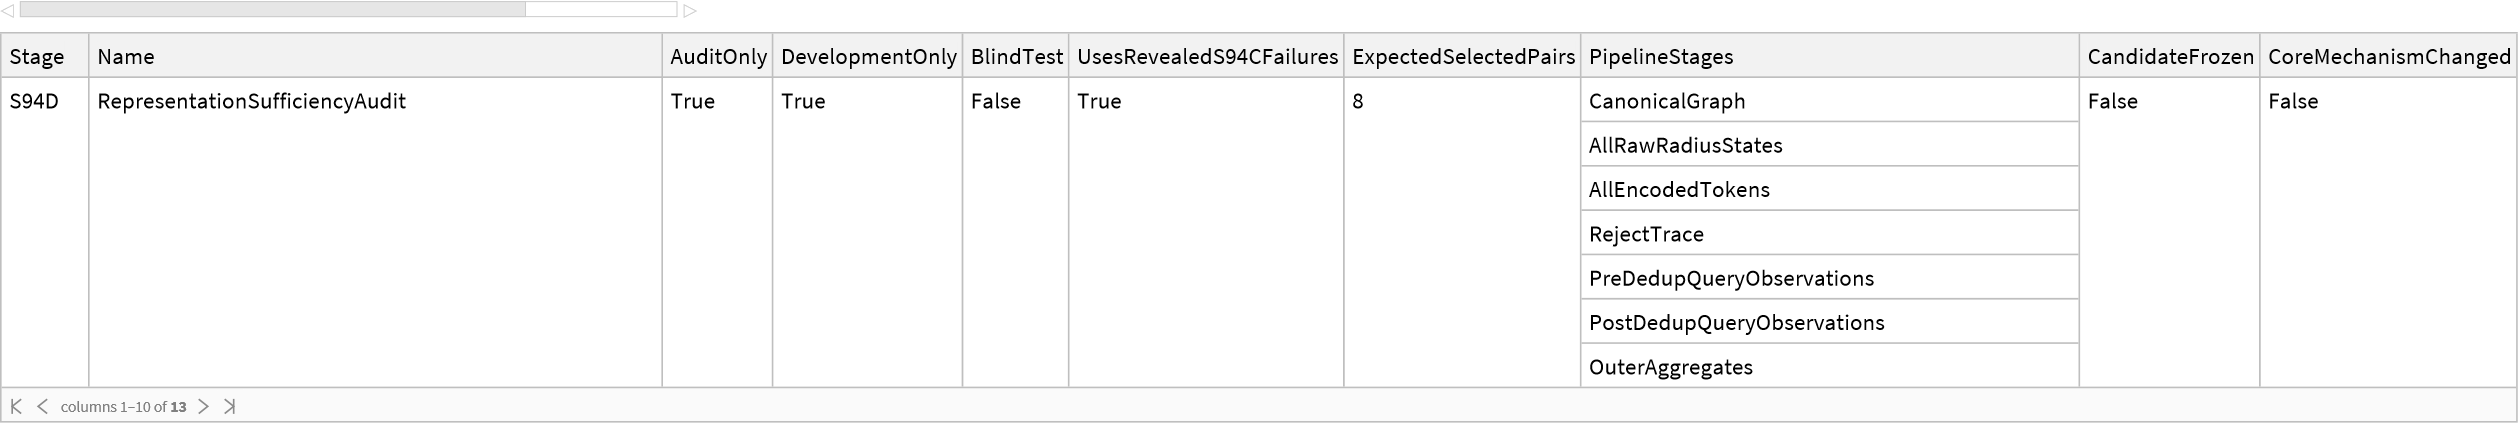

In [2055]:
If[!TrueQ[preflightPassed94D],
Print["S94D blocked: preflight was not passed in this kernel."];Abort[]];

ClearAll[ContextAction94D,T94D,Case94D,ReferenceAction94D,NodeRole94D,
EncodePair94D,DiamondAfterDoubleAfterHierarchical94D,
HierarchicalAfterDiamondAfterDouble94D,DiamondAfterHierarchicalAfterDouble94D,
DoubleAfterHierarchicalAfterDiamond94D,TopologyTransform94D,
ExpectedContractions94D,RoleStatsTwelve94D,RoleMomentVector94D,
RoleInteractionVector94D,RoleEnhancedVector94D,RoleHistogramStats94D,
RoleHistogramVector94D,PrepareWorld94D,PrepareScenario94D,
RepresentationVector94D,FitAntisymmetricReadout94D,
ScoreAntisymmetricReadout94D,FoldMemberQ94D,EvaluateCandidate94D,
RepresentationAudit94D,AxisSummary94D,TestDefinitionBundle94D,
ReadoutDefinitionBundle94D];

contextPatterns94D={"AlternatingEven","AlternatingOdd","BlockHalf","TernarySparse"};
ContextAction94D[i_Integer,pattern_String,branchCount_Integer]:=Switch[pattern,
"AlternatingEven",If[EvenQ[i],"Continue","Stop"],
"AlternatingOdd",If[OddQ[i],"Continue","Stop"],
"BlockHalf",If[i<=Ceiling[branchCount/2],"Continue","Stop"],
"TernarySparse",If[Mod[i,3]===0,"Continue","Stop"],
_,"Undefined"];

T94D[depth_Integer,target_String,answer_Integer,seed_Integer,
branchCount_Integer,contextPattern_String]:=Module[
{bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,main,perm,anc,
branchAction,i},
bb=1000000000 seed;K=bb+1;
c=Table[bb+100+i,{i,branchCount}];v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[Table[{DirectedEdge[K,c[[i]]],DirectedEdge[c[[i]],v[[i]]]},{i,branchCount}],1];
Do[ib=bb+20000000 i;m=ib+1;safe=ib+2;u=ib+3;dummy=ib+4;
r1=ib+10;r2=ib+20;wrong=c[[1+Mod[i,branchCount]]];
main=Join[P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],{DirectedEdge[r1,m],DirectedEdge[r2,m]},
P59[q[[i]],safe,depth+1,ib+3000000]];
branchAction=If[i===answer,target,ContextAction94D[i,contextPattern,branchCount]];
perm=If[branchAction==="Continue",
{DirectedEdge[m,c[[i]]],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]},
{DirectedEdge[m,wrong],DirectedEdge[safe,c[[i]]],DirectedEdge[u,dummy]}];
anc=Join[A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]];
e=Join[e,main,perm,anc];AppendTo[f,m],{i,branchCount}];
{{Union[e],q,K,v,c,f},answer}];

Case94D[depth_Integer,answer_Integer,target_String,topologyIndex_Integer,
contextIndex_Integer,contextPattern_String]:=T94D[depth,target,answer,
94300000+10000 topologyIndex+1000 contextIndex+10 depth,13,contextPattern];

ReferenceAction94D[c_List]:=Module[{x=c[[1]],answer=c[[2]],branchCount,e,m,
safe,u,dummy,correct,wrong,continueEdges,stopEdges},
branchCount=Length[x[[6]]];e=x[[1]];m=x[[6,answer]];safe=m+1;u=m+2;
dummy=m+3;correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={DirectedEdge[m,correct],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]};
stopEdges={DirectedEdge[m,wrong],DirectedEdge[safe,correct],DirectedEdge[u,dummy]};
Which[And@@(MemberQ[e,#]&/@continueEdges),"Continue",
And@@(MemberQ[e,#]&/@stopEdges),"Stop",True,"Undefined"]];

NodeRole94D[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];branchCount=Length[x[[6]]];m=x[[6,answer]];
correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];dummy=m+3;
querySources={m,m+1,m+2};queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",True,"OtherReject"];
<|"Role"->role,"QueryBranchRelated"->MemberQ[queryBranch,originalNode]|>];

EncodePair94D[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[{<|"Grammar"->"S94DExpandedRoleAwareDevelopment",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled","StatePairs"->{pair}|>},
frozenCandidate86E["EncoderParams"],frozenCandidate86E["K"]];
First[encoded["Codes"]]];

DiamondAfterDoubleAfterHierarchical94D[c_List]:=
DiamondIn72[DoubleDiamondIn79[HierarchicalDiamondIn80[c]]];
HierarchicalAfterDiamondAfterDouble94D[c_List]:=
HierarchicalDiamondIn80[DiamondIn72[DoubleDiamondIn79[c]]];
DiamondAfterHierarchicalAfterDouble94D[c_List]:=
DiamondIn72[HierarchicalDiamondIn80[DoubleDiamondIn79[c]]];
DoubleAfterHierarchicalAfterDiamond94D[c_List]:=
DoubleDiamondIn79[HierarchicalDiamondIn80[DiamondIn72[c]]];
TopologyTransform94D[topology_String,c_List]:=Switch[topology,
"DiamondAfterDoubleAfterHierarchical",DiamondAfterDoubleAfterHierarchical94D[c],
"HierarchicalAfterDiamondAfterDouble",HierarchicalAfterDiamondAfterDouble94D[c],
"DiamondAfterHierarchicalAfterDouble",DiamondAfterHierarchicalAfterDouble94D[c],
"DoubleAfterHierarchicalAfterDiamond",DoubleAfterHierarchicalAfterDiamond94D[c],
_,$Failed];
ExpectedContractions94D[baseCase_List]:=6 DecisionIncomingEdgeCount79B[baseCase];

roleOrder94D={"QueriedDecision","QueriedMediatorSource",
"QueriedCorrectDestination","QueriedWrongDestination","QueriedDummyDestination"};
interactionRolePairs94D={{1,2},{1,3},{1,4},{3,4},{3,5},{4,5}};
RoleStatsTwelve94D[observations_List,role_String]:=Module[{selected,codes,a,b,d},
selected=Select[observations,SameQ[Lookup[#,"Role"],role]&];
codes=Lookup[selected,"Code",{}];
If[Length[codes]===0,Return[ConstantArray[0,12]]];
a=codes[[All,1]];b=codes[[All,2]];d=a-b;
{Length[codes],Total[a],Total[b],Total[a^2],Total[b^2],Total[a b],
Total[d],Total[Abs[d]],Total[d^2],Max[a],Max[b],Max[Abs[d]]}];
RoleMomentVector94D[observations_List]:=Flatten[
RoleStatsTwelve94D[observations,#]&/@roleOrder94D];
RoleInteractionVector94D[observations_List]:=Module[{stats},
stats=RoleStatsTwelve94D[observations,#]&/@roleOrder94D;
Flatten[(stats[[#[[1]]]] stats[[#[[2]]]])&/@interactionRolePairs94D]];
RoleEnhancedVector94D[observations_List]:=Join[
RoleMomentVector94D[observations],RoleInteractionVector94D[observations]];
RoleHistogramStats94D[observations_List,role_String]:=Module[
{selected,codes,a,b,d},
selected=Select[observations,SameQ[Lookup[#,"Role"],role]&];
codes=Lookup[selected,"Code",{}];
If[Length[codes]===0,Return[ConstantArray[0,99]]];
a=codes[[All,1]];b=codes[[All,2]];d=1+Mod[a-b,33];
Join[BinCounts[a,{0.5,33.5,1}],BinCounts[b,{0.5,33.5,1}],
BinCounts[d,{0.5,33.5,1}]]];
RoleHistogramVector94D[observations_List]:=Flatten[
RoleHistogramStats94D[observations,#]&/@roleOrder94D];

PrepareWorld94D[topology_String,topologyIndex_Integer,contextPattern_String,
contextIndex_Integer,depth_Integer,target_String,answer_Integer]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,observations,
queryObservations,originalNode,pair,roleInfo,globalVector,roleMomentVector,
roleEnhancedVector,roleHistogramVector,nonQueryActions},
baseCase=Case94D[depth,answer,target,topologyIndex,contextIndex,contextPattern];
topologyCase=TopologyTransform94D[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions94D[baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[Length[trace["Rejects"]]===0,{},
DeleteDuplicates[trace["Rejects"][[All,2]]]];
observations=Map[Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole94D[originalNode,canonicalCase,answer];
<|"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair94D[pair]|>],packedNodes];
queryObservations=Select[observations,TrueQ[Lookup[#,"QueryBranchRelated",False]]&];
globalVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
roleMomentVector=RoleMomentVector94D[queryObservations];
roleEnhancedVector=RoleEnhancedVector94D[queryObservations];
roleHistogramVector=RoleHistogramVector94D[queryObservations];
nonQueryActions=ContextAction94D[#,contextPattern,13]&/@DeleteCases[Range[13],answer];
<|"Topology"->topology,"TopologyIndex"->topologyIndex,
"ContextPattern"->contextPattern,"ContextIndex"->contextIndex,
"Depth"->depth,"Answer"->answer,"Target"->target,
"ReferenceAction"->ReferenceAction94D[canonicalCase],
"NonQueryContinueBranches"->Count[nonQueryActions,"Continue"],
"NonQueryStopBranches"->Count[nonQueryActions,"Stop"],
"GlobalVector"->globalVector,"RoleMomentVector"->roleMomentVector,
"RoleEnhancedVector"->roleEnhancedVector,
"RoleHistogramVector"->roleHistogramVector,
"QueryObservationCount"->Length[queryObservations],
"QueryRoleCounts"->AssociationMap[
Count[Lookup[queryObservations,"Role"],#]&,roleOrder94D],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],expectedContractions],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"TraceSeconds"->traceSeconds|>];

PrepareScenario94D[topology_String,topologyIndex_Integer,contextPattern_String,
contextIndex_Integer,depth_Integer]:=Module[{continueWorlds,stopWorlds,pairs,key},
key=StringRiffle[{topology,contextPattern,ToString[depth]},"|"];
continueWorlds=Table[PrepareWorld94D[topology,topologyIndex,contextPattern,
contextIndex,depth,"Continue",answer],{answer,13}];
stopWorlds=Table[PrepareWorld94D[topology,topologyIndex,contextPattern,
contextIndex,depth,"Stop",answer],{answer,13}];
pairs=MapThread[Function[{continue,stop},<|
"ScenarioKey"->key,"Topology"->topology,"TopologyIndex"->topologyIndex,
"ContextPattern"->contextPattern,"ContextIndex"->contextIndex,
"Depth"->depth,"Answer"->continue["Answer"],
"ContinueWorld"->continue,"StopWorld"->stop,
"GlobalDifference"->continue["GlobalVector"]-stop["GlobalVector"],
"RoleMomentDifference"->continue["RoleMomentVector"]-stop["RoleMomentVector"],
"RoleEnhancedDifference"->continue["RoleEnhancedVector"]-stop["RoleEnhancedVector"],
"RoleHistogramDifference"->continue["RoleHistogramVector"]-stop["RoleHistogramVector"],
"CombinedDifference"->Join[
continue["GlobalVector"]-stop["GlobalVector"],
continue["RoleEnhancedVector"]-stop["RoleEnhancedVector"],
continue["RoleHistogramVector"]-stop["RoleHistogramVector"]],
"ReferenceRelationCorrect"->And[
SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]]|>],{continueWorlds,stopWorlds}];
<|"ScenarioKey"->key,"Topology"->topology,"TopologyIndex"->topologyIndex,
"ContextPattern"->contextPattern,"ContextIndex"->contextIndex,
"Depth"->depth,"Pairs"->pairs,"ContinueWorlds"->continueWorlds,
"StopWorlds"->stopWorlds|>];

RepresentationVector94D[row_Association,representation_String]:=Switch[representation,
"Global27",row["GlobalDifference"],
"RoleMoment60",row["RoleMomentDifference"],
"RoleEnhanced132",row["RoleEnhancedDifference"],
"RoleHistogram495",row["RoleHistogramDifference"],
"Combined654",row["CombinedDifference"],_,$Failed];

FitAntisymmetricReadout94D[rows_List,representation_String,
family_String,lambda_?NumericQ]:=Module[
{differences,scale,z,mu,covariance,variance,weights},
differences=RepresentationVector94D[#,representation]&/@rows;
If[!MatrixQ[differences,NumericQ],Return[$Failed]];
scale=Sqrt[Mean[#^2]]&/@Transpose[differences];
scale=Map[If[!NumericQ[#]||Abs[N[#]]<10^-12,1.,N[#]]&,scale];
z=N[(#/scale)&/@differences];mu=Mean[z];
covariance=Transpose[z].z/Length[z]-Outer[Times,mu,mu];
variance=Diagonal[covariance];
weights=Switch[family,"Centroid",mu,
"DiagonalRidge",mu/(variance+lambda),
"FullRidge",Quiet@Check[
LinearSolve[covariance+lambda IdentityMatrix[Length[mu]],mu],$Failed],
_,$Failed];
If[!VectorQ[weights,NumericQ],Return[$Failed]];
<|"Representation"->representation,"Family"->family,
"Lambda"->lambda,"Scale"->scale,"Weights"->weights|>];
ScoreAntisymmetricReadout94D[model_Association,difference_List]:=
N[Total[model["Weights"] (difference/model["Scale"])]];

FoldMemberQ94D[row_Association,fold_Association]:=Switch[fold["Axis"],
"Topology",SameQ[row["Topology"],fold["Heldout"]],
"ContextPattern",SameQ[row["ContextPattern"],fold["Heldout"]],
"Depth",SameQ[row["Depth"],fold["Heldout"]],
"Answer",SameQ[row["Answer"],fold["Heldout"]],
"Scenario",SameQ[row["ScenarioKey"],fold["Heldout"]],_,False];
EvaluateCandidate94D[rows_List,folds_List,spec_Association]:=Module[
{foldRows},foldRows=Map[Function[fold,Module[{train,test,model,scores},
test=Select[rows,TrueQ[FoldMemberQ94D[#,fold]]&];
train=Select[rows,!TrueQ[FoldMemberQ94D[#,fold]]&];
model=FitAntisymmetricReadout94D[train,spec["Representation"],
spec["Family"],spec["Lambda"]];
scores=If[AssociationQ[model],ScoreAntisymmetricReadout94D[model,
RepresentationVector94D[#,spec["Representation"]]]&/@test,{}];
<|"Axis"->fold["Axis"],"Heldout"->ToString[fold["Heldout"]],
"Cases"->Length[test],"Correct"->Count[scores,x_/;x>0],
"ZeroScores"->Count[scores,x_/;Abs[x]<10^-12],
"Accuracy"->If[Length[test]>0,N[Count[scores,x_/;x>0]/Length[test]],0.],
"MinimumMargin"->If[Length[scores]>0,Min[scores],-Infinity]|>]],folds];
Join[spec,<|"Folds"->Length[foldRows],"Cases"->Total@Lookup[foldRows,"Cases"],
"Correct"->Total@Lookup[foldRows,"Correct"],
"Accuracy"->N[Total@Lookup[foldRows,"Correct"]/Total@Lookup[foldRows,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[foldRows,"Accuracy"],
"ZeroScores"->Total@Lookup[foldRows,"ZeroScores"],
"MinimumMargin"->Min@Lookup[foldRows,"MinimumMargin"],
"FoldResults"->foldRows|>]];

RepresentationAudit94D[rows_List,representation_String]:=Module[
{vectors,unique,oppositeConflicts},
vectors=RepresentationVector94D[#,representation]&/@rows;
unique=DeleteDuplicates[vectors];oppositeConflicts=Intersection[unique,-unique];
<|"Representation"->representation,"Dimension"->Length[First[vectors]],
"ZeroVectors"->Count[vectors,ConstantArray[0,Length[First[vectors]]]],
"UniqueVectors"->Length[unique],
"AntisymmetricAliasConflicts"->Length[oppositeConflicts]|>];
AxisSummary94D[foldRows_List]:=Map[Function[axis,Module[{rows},
rows=Select[foldRows,SameQ[Lookup[#,"Axis"],axis]&];
<|"Axis"->axis,"Folds"->Length[rows],"Cases"->Total@Lookup[rows,"Cases"],
"Correct"->Total@Lookup[rows,"Correct"],
"Accuracy"->N[Total@Lookup[rows,"Correct"]/Total@Lookup[rows,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[rows,"Accuracy"]|>]],
{"Topology","ContextPattern","Depth","Answer","Scenario"}];

TestDefinitionBundle94D[]:={DownValues[ContextAction94D],DownValues[T94D],
DownValues[Case94D],DownValues[ReferenceAction94D],DownValues[NodeRole94D],
DownValues[EncodePair94D],DownValues[DiamondAfterDoubleAfterHierarchical94D],
DownValues[HierarchicalAfterDiamondAfterDouble94D],
DownValues[DiamondAfterHierarchicalAfterDouble94D],
DownValues[DoubleAfterHierarchicalAfterDiamond94D],DownValues[TopologyTransform94D],
DownValues[ExpectedContractions94D],DownValues[RoleStatsTwelve94D],
DownValues[RoleMomentVector94D],DownValues[RoleInteractionVector94D],
DownValues[RoleEnhancedVector94D],DownValues[RoleHistogramStats94D],
DownValues[RoleHistogramVector94D],DownValues[PrepareWorld94D],
DownValues[PrepareScenario94D]};
ReadoutDefinitionBundle94D[]:={DownValues[RepresentationVector94D],
DownValues[FitAntisymmetricReadout94D],DownValues[ScoreAntisymmetricReadout94D],
DownValues[FoldMemberQ94D],DownValues[EvaluateCandidate94D],
DownValues[RepresentationAudit94D],DownValues[AxisSummary94D]};

ClearAll[TraceWorldStages94D,PairStageAudit94D,StageSignature94D,
DifferentQ94D,FirstLossDiagnosis94D,AuditDefinitionBundle94D];
StageSignature94D[x_]:=Hash[x,"SHA256","HexString"];
DifferentQ94D[a_,b_]:=!SameQ[a,b];

TraceWorldStages94D[row_Association,target_String]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,traceSeconds,trace,
levels,pack,vertexList,allPackedNodes,allOriginalNodes,rawPairs,allRawMap,
allCodeMap,queryPackedNodes,queryOriginalNodes,rejectPackedSequence,
rejectOriginalSequence,queryRejectPackedSequence,preDedupPackedSequence,
postDedupPackedNodes,makeObservation,allRejectObservations,
preDedupQueryObservations,postDedupQueryObservations,globalVector,
roleMomentVector,roleEnhancedVector,roleHistogramVector},
baseCase=Case94D[row["Depth"],row["Answer"],target,row["TopologyIndex"],
row["ContextIndex"],row["ContextPattern"]];
topologyCase=TopologyTransform94D[row["Topology"],baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];allPackedNodes=Range[Length[vertexList]];
allOriginalNodes=vertexList;
rawPairs=({Lookup[levels[[3]],#],Lookup[levels[[4]],#]}&)/@allPackedNodes;
allRawMap=AssociationThread[allOriginalNodes,rawPairs];
allCodeMap=AssociationThread[allOriginalNodes,EncodePair94D/@rawPairs];
queryPackedNodes=Select[allPackedNodes,TrueQ[
NodeRole94D[vertexList[[#]],canonicalCase,row["Answer"]]["QueryBranchRelated"]]&];
queryOriginalNodes=vertexList[[queryPackedNodes]];
rejectPackedSequence=If[Length[trace["Rejects"]]===0,{},trace["Rejects"][[All,2]]];
rejectOriginalSequence=If[Length[rejectPackedSequence]===0,{},
vertexList[[rejectPackedSequence]]];
queryRejectPackedSequence=Select[rejectPackedSequence,
MemberQ[queryPackedNodes,#]&];
preDedupPackedSequence=queryRejectPackedSequence;
postDedupPackedNodes=DeleteDuplicates[queryRejectPackedSequence];
makeObservation=Function[packedNode,Module[{originalNode,roleInfo,pair},
originalNode=vertexList[[packedNode]];
roleInfo=NodeRole94D[originalNode,canonicalCase,row["Answer"]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
<|"OriginalNode"->originalNode,"Role"->roleInfo["Role"],
"RawStateHash"->StageSignature94D[pair],"Code"->EncodePair94D[pair]|>]];
allRejectObservations=makeObservation/@DeleteDuplicates[rejectPackedSequence];
preDedupQueryObservations=makeObservation/@preDedupPackedSequence;
postDedupQueryObservations=makeObservation/@postDedupPackedNodes;
globalVector=TCCTWorldVectorS87D[<|"Observations"->allRejectObservations|>];
roleMomentVector=RoleMomentVector94D[postDedupQueryObservations];
roleEnhancedVector=RoleEnhancedVector94D[postDedupQueryObservations];
roleHistogramVector=RoleHistogramVector94D[postDedupQueryObservations];
<|"Target"->target,"ReferenceAction"->ReferenceAction94D[canonicalCase],
"CanonicalEdges"->canonicalCase[[1,1]],
"AllRawMap"->allRawMap,"AllCodeMap"->allCodeMap,
"QueryRawMap"->KeyTake[allRawMap,queryOriginalNodes],
"QueryCodeMap"->KeyTake[allCodeMap,queryOriginalNodes],
"RejectOriginalSequence"->rejectOriginalSequence,
"PreDedupQueryObservations"->preDedupQueryObservations,
"PostDedupQueryObservations"->postDedupQueryObservations,
"GlobalVector"->globalVector,"RoleMomentVector"->roleMomentVector,
"RoleEnhancedVector"->roleEnhancedVector,
"RoleHistogramVector"->roleHistogramVector,
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],
ExpectedContractions94D[baseCase]],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"TraceSeconds"->traceSeconds|>];

FirstLossDiagnosis94D[flags_Association]:=Which[
!TrueQ[flags["CanonicalGraphDistinguishable"]],"INVALID_IDENTICAL_COUNTERFACTUAL_GRAPHS",
!TrueQ[flags["AllRawStatesDistinguishable"]],"RAW_RADIUS_STATE_COLLAPSE",
!TrueQ[flags["AllEncodedTokensDistinguishable"]],"FROZEN_ENCODER_COMPRESSION_LOSS",
!TrueQ[flags["RejectTraceDistinguishable"]],"CORE_REJECT_TRACE_SELECTION_LOSS",
!TrueQ[flags["PreDedupQueryObservationsDistinguishable"]],"QUERY_OBSERVATION_SCOPE_LOSS",
!TrueQ[flags["PostDedupQueryObservationsDistinguishable"]],"DEDUPLICATION_INFORMATION_LOSS",
True,"OUTER_AGGREGATION_LOSS"];

PairStageAudit94D[row_Association]:=Module[{continue,stop,flags,diagnosis},
continue=TraceWorldStages94D[row,"Continue"];
stop=TraceWorldStages94D[row,"Stop"];
flags=<|
"CanonicalGraphDistinguishable"->DifferentQ94D[continue["CanonicalEdges"],stop["CanonicalEdges"]],
"AllRawStatesDistinguishable"->DifferentQ94D[continue["AllRawMap"],stop["AllRawMap"]],
"QueryRawStatesDistinguishable"->DifferentQ94D[continue["QueryRawMap"],stop["QueryRawMap"]],
"AllEncodedTokensDistinguishable"->DifferentQ94D[continue["AllCodeMap"],stop["AllCodeMap"]],
"QueryEncodedTokensDistinguishable"->DifferentQ94D[continue["QueryCodeMap"],stop["QueryCodeMap"]],
"RejectTraceDistinguishable"->DifferentQ94D[continue["RejectOriginalSequence"],stop["RejectOriginalSequence"]],
"PreDedupQueryObservationsDistinguishable"->DifferentQ94D[
continue["PreDedupQueryObservations"],stop["PreDedupQueryObservations"]],
"PostDedupQueryObservationsDistinguishable"->DifferentQ94D[
continue["PostDedupQueryObservations"],stop["PostDedupQueryObservations"]],
"GlobalAggregateDistinguishable"->DifferentQ94D[continue["GlobalVector"],stop["GlobalVector"]],
"RoleMomentAggregateDistinguishable"->DifferentQ94D[
continue["RoleMomentVector"],stop["RoleMomentVector"]],
"RoleEnhancedAggregateDistinguishable"->DifferentQ94D[
continue["RoleEnhancedVector"],stop["RoleEnhancedVector"]],
"RoleHistogramAggregateDistinguishable"->DifferentQ94D[
continue["RoleHistogramVector"],stop["RoleHistogramVector"]]|>;
diagnosis=FirstLossDiagnosis94D[flags];
Join[KeyTake[row,{"ScenarioKey","Topology","TopologyIndex","ContextPattern",
"ContextIndex","Depth","Answer"}],flags,<|
"Diagnosis"->diagnosis,
"ReferenceActionsCorrect"->And[SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],
"RegeneratedGlobalDifferenceMatches"->SameQ[
continue["GlobalVector"]-stop["GlobalVector"],row["GlobalDifference"]],
"RegeneratedRoleMomentDifferenceMatches"->SameQ[
continue["RoleMomentVector"]-stop["RoleMomentVector"],row["RoleMomentDifference"]],
"RegeneratedRoleEnhancedDifferenceMatches"->SameQ[
continue["RoleEnhancedVector"]-stop["RoleEnhancedVector"],row["RoleEnhancedDifference"]],
"RegeneratedRoleHistogramDifferenceMatches"->SameQ[
continue["RoleHistogramVector"]-stop["RoleHistogramVector"],row["RoleHistogramDifference"]],
"CanonicalizationValid"->And[continue["CanonicalCaseExactlyBase"],
stop["CanonicalCaseExactlyBase"],continue["ContractionCountCorrect"],
stop["ContractionCountCorrect"],continue["ProtectedNodesPreserved"],
stop["ProtectedNodesPreserved"]],
"TracesValid"->And[continue["TerminatedNaturally"],stop["TerminatedNaturally"],
!continue["HitSafetyCap"],!stop["HitSafetyCap"]],
"TraceSeconds"->continue["TraceSeconds"]+stop["TraceSeconds"]|>]];

AuditDefinitionBundle94D[]:={DownValues[TraceWorldStages94D],
DownValues[PairStageAudit94D],DownValues[StageSignature94D],
DownValues[DifferentQ94D],DownValues[FirstLossDiagnosis94D]};
testDefinitionHashBefore94D=Hash[TestDefinitionBundle94D[],"SHA256","HexString"];
auditDefinitionHashBefore94D=Hash[AuditDefinitionBundle94D[],"SHA256","HexString"];
protocol94D=<|"Stage"->"S94D","Name"->"RepresentationSufficiencyAudit",
"AuditOnly"->True,"DevelopmentOnly"->True,"BlindTest"->False,
"UsesRevealedS94CFailures"->True,"ExpectedSelectedPairs"->8,
"PipelineStages"->{"CanonicalGraph","AllRawRadiusStates","AllEncodedTokens",
"RejectTrace","PreDedupQueryObservations","PostDedupQueryObservations",
"OuterAggregates"},"CandidateFrozen"->False,"CoreMechanismChanged"->False|>;
protocolHash94D=Hash[Normal[protocol94D],"SHA256","HexString"];
Dataset[{Join[protocol94D,<|"ProtocolHash"->protocolHash94D,
"TestDefinitionHash"->testDefinitionHashBefore94D,
"AuditDefinitionHash"->auditDefinitionHashBefore94D|>]}]


Dataset[{<|ScenarioKey -> DiamondAfterDoubleAfterHierarchical|TernarySparse|17, 
 
>     Topology -> DiamondAfterDoubleAfterHierarchical, TopologyIndex -> 1, 
 
>     ContextPattern -> TernarySparse, ContextIndex -> 4, Depth -> 17, Answer -> 8, 
 
>     CanonicalGraphDistinguishable -> True, AllRawStatesDistinguishable -> True, 
 
>     QueryRawStatesDistinguishable -> True, AllEncodedTokensDistinguishable -> True, 
 
>     QueryEncodedTokensDistinguishable -> True, RejectTraceDistinguishable -> False, 
 
>     PreDedupQueryObservationsDistinguishable -> True, 
 
>     PostDedupQueryObservationsDistinguishable -> True, 
 
>     GlobalAggregateDistinguishable -> False, 
 
>     RoleMomentAggregateDistinguishable -> False, 
 
>     RoleEnhancedAggregateDistinguishable -> False, 
 
>     RoleHistogramAggregateDistinguishable -> False, 
 
>     Diagnosis -> CORE_REJECT_TRACE_SELECTION_LOSS, ReferenceActionsCorrect -> True, 
 
>     RegeneratedGlobalDifferenceMatches -> True, 
 
>     RegeneratedRoleMomentDifferenceMatches -> True, 
 
>     RegeneratedRoleEnhancedDifferenceMatches -> True, 
 
>     RegeneratedRoleHistogramDifferenceMatches -> True, CanonicalizationValid -> True, 
 
>     TracesValid -> True, TraceSeconds -> 0.242211|>, 
 
>    <|ScenarioKey -> DiamondAfterDoubleAfterHierarchical|TernarySparse|31, 
 
>     Topology -> DiamondAfterDoubleAfterHierarchical, TopologyIndex -> 1, 
 
>     ContextPattern -> TernarySparse, ContextIndex -> 4, Depth -> 31, Answer -> 8, 
 
>     CanonicalGraphDistinguishable -> True, AllRawStatesDistinguishable -> True, 
 
>     QueryRawStatesDistinguishable -> True, AllEncodedTokensDistinguishable -> True, 
 
>     QueryEncodedTokensDistinguishable -> True, RejectTraceDistinguishable -> False, 
 
>     PreDedupQueryObservationsDistinguishable -> True, 
 
>     PostDedupQueryObservationsDistinguishable -> True, 
 
>     GlobalAggregateDistinguishable -> False, 
 
>     RoleMomentAggregateDistinguishable -> False, 
 
>     RoleEnhancedAggregateDistinguishable -> False, 
 
>     RoleHistogramAggregateDistinguishable -> False, 
 
>     Diagnosis -> CORE_REJECT_TRACE_SELECTION_LOSS, ReferenceActionsCorrect -> True, 
 
>     RegeneratedGlobalDifferenceMatches -> True, 
 
>     RegeneratedRoleMomentDifferenceMatches -> True, 
 
>     RegeneratedRoleEnhancedDifferenceMatches -> True, 
 
>     RegeneratedRoleHistogramDifferenceMatches -> True, CanonicalizationValid -> True, 
 
>     TracesValid -> True, TraceSeconds -> 0.954503|>, 
 
>    <|ScenarioKey -> HierarchicalAfterDiamondAfterDouble|TernarySparse|17, 
 
>     Topology -> HierarchicalAfterDiamondAfterDouble, TopologyIndex -> 2, 
 
>     ContextPattern -> TernarySparse, ContextIndex -> 4, Depth -> 17, Answer -> 8, 
 
>     CanonicalGraphDistinguishable -> True, AllRawStatesDistinguishable -> True, 
 
>     QueryRawStatesDistinguishable -> True, AllEncodedTokensDistinguishable -> True, 
 
>     QueryEncodedTokensDistinguishable -> True, RejectTraceDistinguishable -> False, 
 
>     PreDedupQueryObservationsDistinguishable -> True, 
 
>     PostDedupQueryObservationsDistinguishable -> True, 
 
>     GlobalAggregateDistinguishable -> False, 
 
>     RoleMomentAggregateDistinguishable -> False, 
 
>     RoleEnhancedAggregateDistinguishable -> False, 
 
>     RoleHistogramAggregateDistinguishable -> False, 
 
>     Diagnosis -> CORE_REJECT_TRACE_SELECTION_LOSS, ReferenceActionsCorrect -> True, 
 
>     RegeneratedGlobalDifferenceMatches -> True, 
 
>     RegeneratedRoleMomentDifferenceMatches -> True, 
 
>     RegeneratedRoleEnhancedDifferenceMatches -> True, 
 
>     RegeneratedRoleHistogramDifferenceMatches -> True, CanonicalizationValid -> True, 
 
>     TracesValid -> True, TraceSeconds -> 0.242049|>, 
 
>    <|ScenarioKey -> HierarchicalAfterDiamondAfterDouble|TernarySparse|31, 
 
>     Topology -> HierarchicalAfterDiamondAfterDouble, TopologyIndex -> 2, 
 
>     ContextPattern -> TernarySparse, ContextIndex -> 4, Depth -> 31, Answer -> 8, 
 
> 
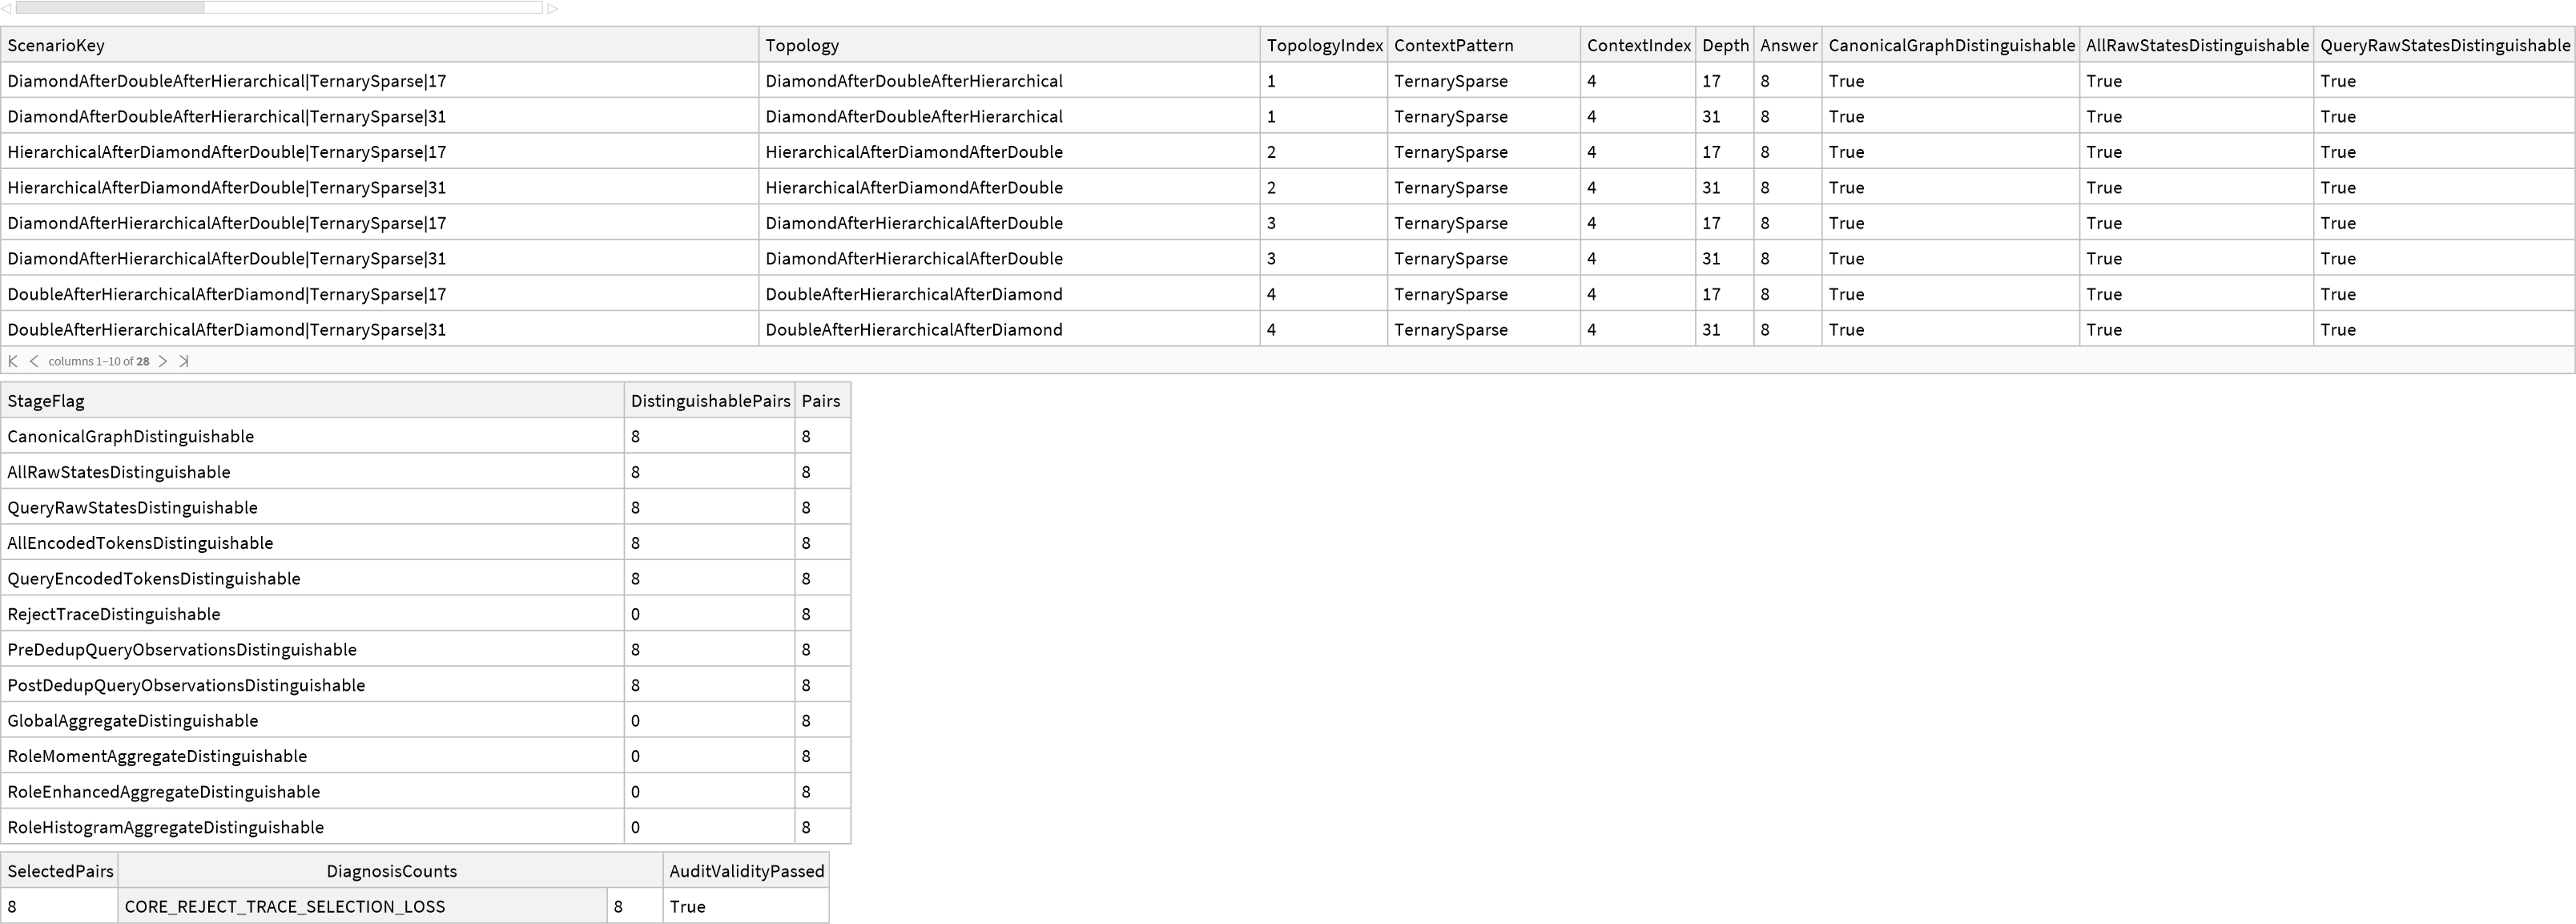

In [2105]:
If[!TrueQ[preflightPassed94D],
Print["S94D blocked before evaluation: preflight is not True."];Abort[]];
s94cRows94D=s94cDiagnosticArtifact94D["Rows"];
zeroDifferenceRows94D=Select[s94cRows94D,And[
Total[Abs[Lookup[#,"GlobalDifference"]]]===0,
Total[Abs[Lookup[#,"RoleMomentDifference"]]]===0,
Total[Abs[Lookup[#,"RoleEnhancedDifference"]]]===0,
Total[Abs[Lookup[#,"RoleHistogramDifference"]]]===0,
Total[Abs[Lookup[#,"CombinedDifference"]]]===0]&];
pairAudits94D=PairStageAudit94D/@zeroDifferenceRows94D;
diagnosisCounts94D=Counts[Lookup[pairAudits94D,"Diagnosis"]];
stageSummary94D=Map[Function[key,<|"StageFlag"->key,
"DistinguishablePairs"->Count[Lookup[pairAudits94D,key],True],
"Pairs"->Length[pairAudits94D]|>],{
"CanonicalGraphDistinguishable","AllRawStatesDistinguishable",
"QueryRawStatesDistinguishable","AllEncodedTokensDistinguishable",
"QueryEncodedTokensDistinguishable","RejectTraceDistinguishable",
"PreDedupQueryObservationsDistinguishable",
"PostDedupQueryObservationsDistinguishable",
"GlobalAggregateDistinguishable","RoleMomentAggregateDistinguishable",
"RoleEnhancedAggregateDistinguishable","RoleHistogramAggregateDistinguishable"}];
auditValidityPassed94D=And[
SameQ[Length[s94cRows94D],416],SameQ[Length[zeroDifferenceRows94D],8],
SameQ[Length[pairAudits94D],8],
And@@Lookup[pairAudits94D,"ReferenceActionsCorrect"],
And@@Lookup[pairAudits94D,"RegeneratedGlobalDifferenceMatches"],
And@@Lookup[pairAudits94D,"RegeneratedRoleMomentDifferenceMatches"],
And@@Lookup[pairAudits94D,"RegeneratedRoleEnhancedDifferenceMatches"],
And@@Lookup[pairAudits94D,"RegeneratedRoleHistogramDifferenceMatches"],
And@@Lookup[pairAudits94D,"CanonicalizationValid"],
And@@Lookup[pairAudits94D,"TracesValid"]];
Column[{Dataset[pairAudits94D],Dataset[stageSummary94D],Dataset[{<|
"SelectedPairs"->Length[zeroDifferenceRows94D],
"DiagnosisCounts"->diagnosisCounts94D,
"AuditValidityPassed"->auditValidityPassed94D|>}]}]


Dataset[{<|Stage -> S94D, Name -> RepresentationSufficiencyAudit, AuditOnly -> True, 
 
>     DevelopmentOnly -> True, BlindTest -> False, UsesRevealedS94CFailures -> True, 
 
>     PreflightPassed -> True, S94CFormalStatus -> 
 
>      DIAGNOSTIC_ONLY_DUE_TO_PRECHECK_HASH_TYPO, SelectedZeroDifferencePairs -> 8, 
 
>     StageSummary -> 
 
>      {<|StageFlag -> CanonicalGraphDistinguishable, DistinguishablePairs -> 8, 
 
>        Pairs -> 8|>, <|StageFlag -> AllRawStatesDistinguishable, 
 
>        DistinguishablePairs -> 8, Pairs -> 8|>, 
 
>       <|StageFlag -> QueryRawStatesDistinguishable, DistinguishablePairs -> 8, 
 
>        Pairs -> 8|>, <|StageFlag -> AllEncodedTokensDistinguishable, 
 
>        DistinguishablePairs -> 8, Pairs -> 8|>, 
 
>       <|StageFlag -> QueryEncodedTokensDistinguishable, DistinguishablePairs -> 8, 
 
>        Pairs -> 8|>, <|StageFlag -> RejectTraceDistinguishable, 
 
>        DistinguishablePairs -> 0, Pairs -> 8|>, 
 
>       <|StageFlag -> PreDedupQueryObservationsDistinguishable, 
 
>        DistinguishablePairs -> 8, Pairs -> 8|>, 
 
>       <|StageFlag -> PostDedupQueryObservationsDistinguishable, 
 
>        DistinguishablePairs -> 8, Pairs -> 8|>, 
 
>       <|StageFlag -> GlobalAggregateDistinguishable, DistinguishablePairs -> 0, 
 
>        Pairs -> 8|>, <|StageFlag -> RoleMomentAggregateDistinguishable, 
 
>        DistinguishablePairs -> 0, Pairs -> 8|>, 
 
>       <|StageFlag -> RoleEnhancedAggregateDistinguishable, DistinguishablePairs -> 0, 
 
>        Pairs -> 8|>, <|StageFlag -> RoleHistogramAggregateDistinguishable, 
 
>        DistinguishablePairs -> 0, Pairs -> 8|>}, 
 
>     PairAudits -> 
 
>      {<|ScenarioKey -> DiamondAfterDoubleAfterHierarchical|TernarySparse|17, 
 
>        Topology -> DiamondAfterDoubleAfterHierarchical, TopologyIndex -> 1, 
 
>        ContextPattern -> TernarySparse, ContextIndex -> 4, Depth -> 17, Answer -> 8, 
 
>        CanonicalGraphDistinguishable -> True, AllRawStatesDistinguishable -> True, 
 
>        QueryRawStatesDistinguishable -> True, AllEncodedTokensDistinguishable -> True, 
 
>        QueryEncodedTokensDistinguishable -> True, RejectTraceDistinguishable -> False, 
 
>        PreDedupQueryObservationsDistinguishable -> True, 
 
>        PostDedupQueryObservationsDistinguishable -> True, 
 
>        GlobalAggregateDistinguishable -> False, 
 
>        RoleMomentAggregateDistinguishable -> False, 
 
>        RoleEnhancedAggregateDistinguishable -> False, 
 
>        RoleHistogramAggregateDistinguishable -> False, 
 
>        Diagnosis -> CORE_REJECT_TRACE_SELECTION_LOSS, ReferenceActionsCorrect -> True, 
 
>        RegeneratedGlobalDifferenceMatches -> True, 
 
>        RegeneratedRoleMomentDifferenceMatches -> True, 
 
>        RegeneratedRoleEnhancedDifferenceMatches -> True, 
 
>        RegeneratedRoleHistogramDifferenceMatches -> True, 
 
>        CanonicalizationValid -> True, TracesValid -> True, TraceSeconds -> 0.242211|>, 
 
>       <|ScenarioKey -> DiamondAfterDoubleAfterHierarchical|TernarySparse|31, 
 
>        Topology -> DiamondAfterDoubleAfterHierarchical, TopologyIndex -> 1, 
 
>        ContextPattern -> TernarySparse, ContextIndex -> 4, Depth -> 31, Answer -> 8, 
 
>        CanonicalGraphDistinguishable -> True, AllRawStatesDistinguishable -> True, 
 
>        QueryRawStatesDistinguishable -> True, AllEncodedTokensDistinguishable -> True, 
 
>        QueryEncodedTokensDistinguishable -> True, RejectTraceDistinguishable -> False, 
 
>        PreDedupQueryObservationsDistinguishable -> True, 
 
>        PostDedupQueryObservationsDistinguishable -> True, 
 
>        GlobalAggregateDistinguishable -> False, 
 
>        RoleMomentAggregateDistinguishable -> False, 
 
>        RoleEnhancedAggregateDistinguishable -> False, 
 
>        RoleHistogramAggregateDistinguishable -> False, 
 
>        Diagnosis -> CORE_REJECT_TRACE_SELECTION_LOSS, ReferenceActionsCorrect -> True, 
 
>        RegeneratedGlobalDifferenceMatches -> Tr
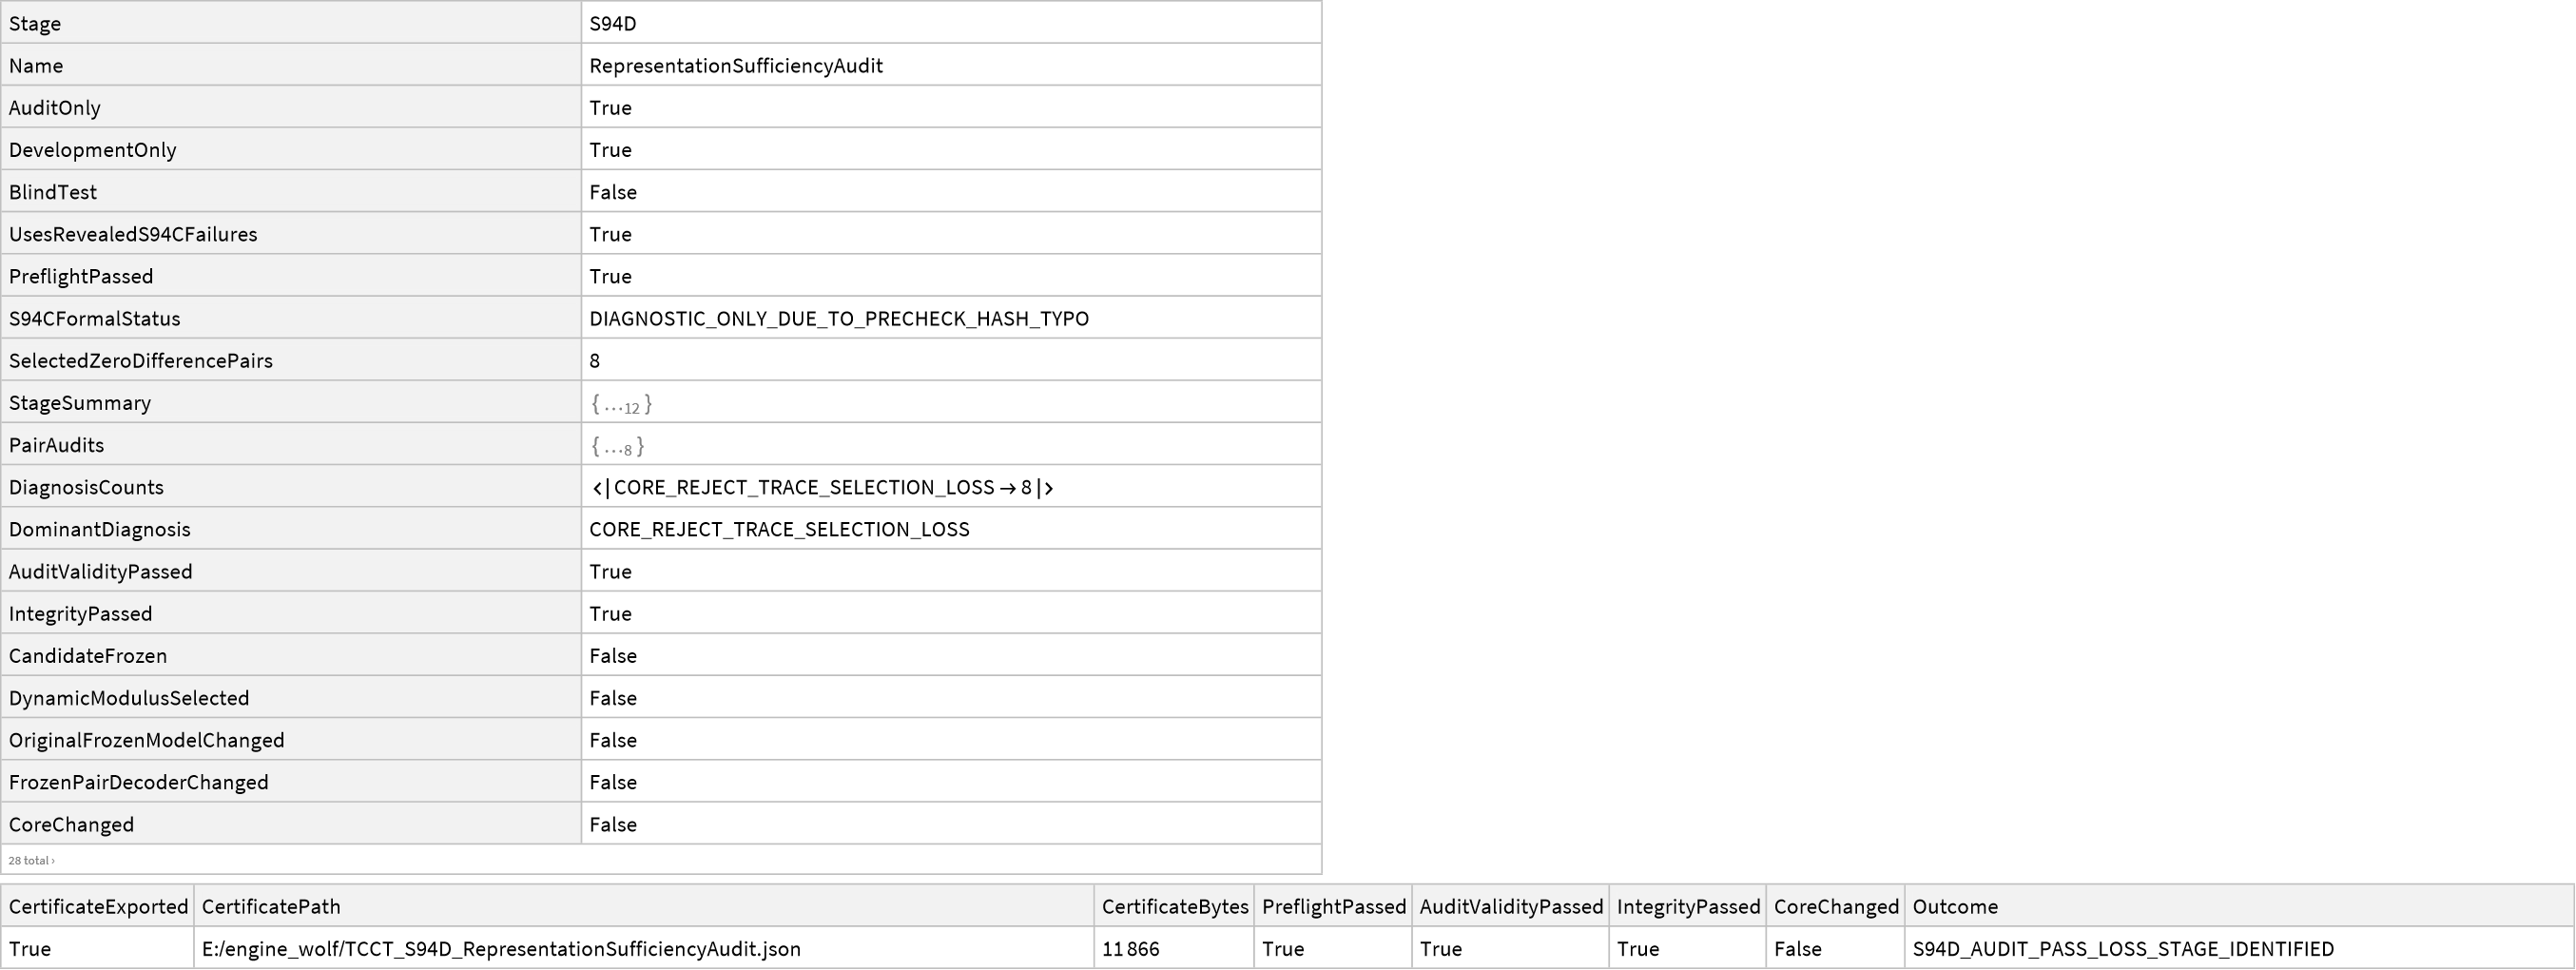

In [2113]:
If[!TrueQ[preflightPassed94D],
Print["S94D blocked before certificate: preflight is not True."];Abort[]];
modelHashAfter94D=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter94D=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashAfter94D=Hash[Normal[baseDecoderRaw94D],"SHA256","HexString"];
pairDecoderObjectHashAfter94D=Hash[Normal[pairDecoderRaw94D],"SHA256","HexString"];
coreHashAfter94D=Hash[CoreDefinitionBundle94D[],"SHA256","HexString"];
canonicalizerHashAfter94D=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashAfter94D=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashAfter94D=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashAfter94D=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashAfter94D=Hash[
PairRuntimeDefinitionBundle94D[],"SHA256","HexString"];
testDefinitionHashAfter94D=Hash[TestDefinitionBundle94D[],"SHA256","HexString"];
auditDefinitionHashAfter94D=Hash[AuditDefinitionBundle94D[],"SHA256","HexString"];
fileHashesAfter94D=FileSHA256Hex94D/@requiredFiles94D;
integrityPassed94D=And[
SameQ[modelHashBefore94D,modelHashAfter94D],
SameQ[k33ObjectHashBefore94D,k33ObjectHashAfter94D],
SameQ[baseDecoderObjectHashBefore94D,baseDecoderObjectHashAfter94D],
SameQ[pairDecoderObjectHashBefore94D,pairDecoderObjectHashAfter94D],
SameQ[coreHashBefore94D,coreHashAfter94D],
SameQ[canonicalizerHashBefore94D,canonicalizerHashAfter94D],
SameQ[interventionHashBefore94D,interventionHashAfter94D],
SameQ[topologyPrimitiveHashBefore94D,topologyPrimitiveHashAfter94D],
SameQ[baseRuntimeDefinitionHashBefore94D,baseRuntimeDefinitionHashAfter94D],
SameQ[pairRuntimeDefinitionHashBefore94D,pairRuntimeDefinitionHashAfter94D],
SameQ[testDefinitionHashBefore94D,testDefinitionHashAfter94D],
SameQ[auditDefinitionHashBefore94D,auditDefinitionHashAfter94D],
SameQ[fileHashesBefore94D,fileHashesAfter94D]];
dominantDiagnosis94D=If[Length[diagnosisCounts94D]===1,
First[Keys[diagnosisCounts94D]],"MULTIPLE_INFORMATION_LOSS_STAGES"];
resultPayload94D=<|"Stage"->"S94D","Name"->"RepresentationSufficiencyAudit",
"AuditOnly"->True,"DevelopmentOnly"->True,"BlindTest"->False,
"UsesRevealedS94CFailures"->True,"PreflightPassed"->preflightPassed94D,
"S94CFormalStatus"->"DIAGNOSTIC_ONLY_DUE_TO_PRECHECK_HASH_TYPO",
"SelectedZeroDifferencePairs"->Length[zeroDifferenceRows94D],
"StageSummary"->stageSummary94D,"PairAudits"->pairAudits94D,
"DiagnosisCounts"->diagnosisCounts94D,"DominantDiagnosis"->dominantDiagnosis94D,
"AuditValidityPassed"->auditValidityPassed94D,
"IntegrityPassed"->integrityPassed94D,
"CandidateFrozen"->False,"DynamicModulusSelected"->False,
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore94D,modelHashAfter94D],
"FrozenPairDecoderChanged"->!SameQ[pairDecoderObjectHashBefore94D,pairDecoderObjectHashAfter94D],
"CoreChanged"->!SameQ[coreHashBefore94D,coreHashAfter94D],
"CanonicalizerChanged"->!SameQ[canonicalizerHashBefore94D,canonicalizerHashAfter94D],
"InterventionCoreChanged"->!SameQ[interventionHashBefore94D,interventionHashAfter94D],
"DeduplicationMechanismChanged"->!SameQ[coreHashBefore94D,coreHashAfter94D],
"UndirectedFreezeMechanismChanged"->!SameQ[coreHashBefore94D,coreHashAfter94D],
"TotalTraceSeconds"->Total@Lookup[pairAudits94D,"TraceSeconds"],
"Outcome"->If[And[TrueQ[preflightPassed94D],TrueQ[auditValidityPassed94D],
TrueQ[integrityPassed94D]],"S94D_AUDIT_PASS_LOSS_STAGE_IDENTIFIED",
"S94D_INVALID_AUDIT_DO_NOT_INTERPRET"],
"SuggestedNextStage"->Switch[dominantDiagnosis94D,
"OUTER_AGGREGATION_LOSS","S94E_REDESIGN_OUTER_AGGREGATION_ONLY",
"DEDUPLICATION_INFORMATION_LOSS","S94E_DEDUPLICATION_SEMANTICS_REVIEW",
"QUERY_OBSERVATION_SCOPE_LOSS","S94E_QUERY_SCOPE_REPRESENTATION_REVIEW",
"FROZEN_ENCODER_COMPRESSION_LOSS","S94E_ENCODER_CAPACITY_REVIEW_NO_CORE_CHANGE",
"CORE_REJECT_TRACE_SELECTION_LOSS","S94E_CORE_MECHANISM_LIMITATION_REVIEW",
"RAW_RADIUS_STATE_COLLAPSE","S94E_RAW_STATE_RADIUS_LIMITATION_REVIEW",
_,"S94E_PAIR_SPECIFIC_LOSS_ANALYSIS"]|>;
resultHash94D=Hash[Normal[resultPayload94D],"SHA256","HexString"];
certificate94D=Append[resultPayload94D,"ResultHash"->resultHash94D];
certificateExportResult94D=Quiet@Check[
Export[resultCertificatePath94D,certificate94D,"RawJSON"],$Failed];
certificateExported94D=StringQ[certificateExportResult94D]&&
FileExistsQ[resultCertificatePath94D]&&FileByteCount[resultCertificatePath94D]>0;
Column[{Dataset[{certificate94D}],Dataset[{<|
"CertificateExported"->certificateExported94D,
"CertificatePath"->resultCertificatePath94D,
"CertificateBytes"->If[FileExistsQ[resultCertificatePath94D],
FileByteCount[resultCertificatePath94D],0],
"PreflightPassed"->preflightPassed94D,"AuditValidityPassed"->auditValidityPassed94D,
"IntegrityPassed"->integrityPassed94D,"CoreChanged"->certificate94D["CoreChanged"],
"Outcome"->certificate94D["Outcome"]|>}]}]
